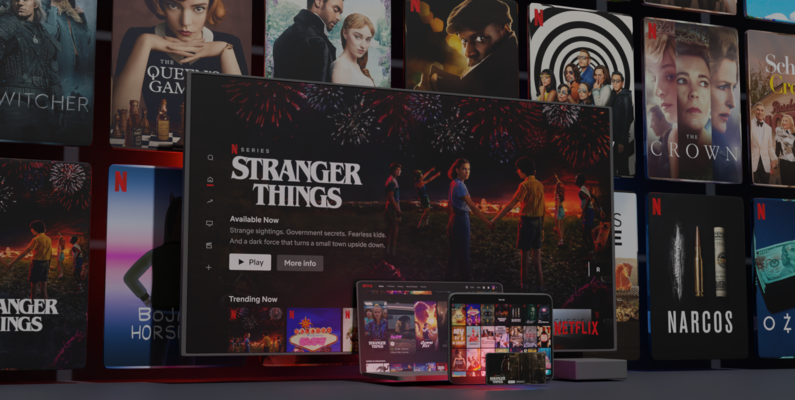

# 📊 Data Analysis Project: Netflix Dataset

## Introduction

In this project, we explore and analyze a dataset related to Netflix content, aiming to extract meaningful insights and patterns. With the rapid growth of streaming platforms, understanding content distribution, trends, and user preferences has become increasingly important for both businesses and data analysts.

This analysis focuses on examining different aspects of the dataset such as content types, release years, genres, and geographical distribution. By applying data cleaning, preprocessing, and visualization techniques, we aim to uncover hidden patterns and provide data-driven conclusions.

The project is implemented using Python and popular data analysis libraries such as **Pandas**, **NumPy**, and **Matplotlib/Seaborn**. The results of this analysis can help in better understanding how content is structured on Netflix and how it has evolved over time.

---

## Objectives

- Perform data cleaning and preprocessing  
- Explore the dataset using descriptive statistics  
- Visualize key trends and patterns  
- Derive actionable insights from the data  

---

## Tools & Technologies

- Python 🐍  
- Pandas  
- NumPy  
- Matplotlib & Seaborn  
- Jupyter Notebook  

---

## Dataset

The dataset was sourced from Kaggle and contains 8,807 rows and 12 columns.


---

> 💡 This project demonstrates how data analysis can turn raw data into valuable insights that support decision-making.

### Import required libraries for data analysis and visualization

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset and display first rows

In [14]:
# read csv 
df1 = pd.read_csv('netflix1.csv')
# show first few rows
df1.head(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [9]:
# data columns
df1.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

### Show number of rows and columns

In [8]:
# shape of dataframe
df1.shape

(8790, 10)

From above , we found that there are 8807 rows × 12 columns


### Display dataset info (data types & missing values)

In [4]:
# show some infos 
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [17]:
df1['date_added'] = pd.to_datetime(df1['date_added'])
df1.dtypes

show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object

From the above, data types is fixed

In [82]:
# check duplicates
df1.duplicated().sum()

np.int64(0)

In [83]:
# check nulls
df1.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
added_year      0
added_month     0
dtype: int64

In [33]:
types_count=df1 ['type'].value_counts()
types_count

type
Movie    6126
Name: count, dtype: int64

### This line filters the DataFrame to select only the rows where the 'type' column is equal to 'Movie

In [88]:
df1[df1['type']=='Movie']
df1.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month
0,s1,Movie,DICK JOHNSON IS DEAD,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90,Documentaries,2021,9
3,s14,Movie,CONFESSIONS OF AN INVISIBLE GIRL,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91,"Children & Family Movies, Comedies",2021,9
4,s8,Movie,SANKOFA,Haile Gerima,United States,2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies",2021,9
6,s10,Movie,THE STARLING,Theodore Melfi,United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",2021,9
7,s939,Movie,MOTU PATLU IN THE GAME OF ZONES,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87,"Children & Family Movies, Comedies, Music & Mu...",2021,5


### Remove text from duration column

In [64]:
df1['duration'] = df1['duration'].str.replace(' min', '')
df1['duration'] = df1['duration'].str.replace(' Season', '')
df1['duration'] = df1['duration'].str.replace(' Seasons', '')

In [71]:
df1.head(2)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month
0,s1,Movie,DICK JOHNSON IS DEAD,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90,Documentaries,2021,9
3,s14,Movie,CONFESSIONS OF AN INVISIBLE GIRL,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91,"Children & Family Movies, Comedies",2021,9


### Compare number of Movies and TV Shows

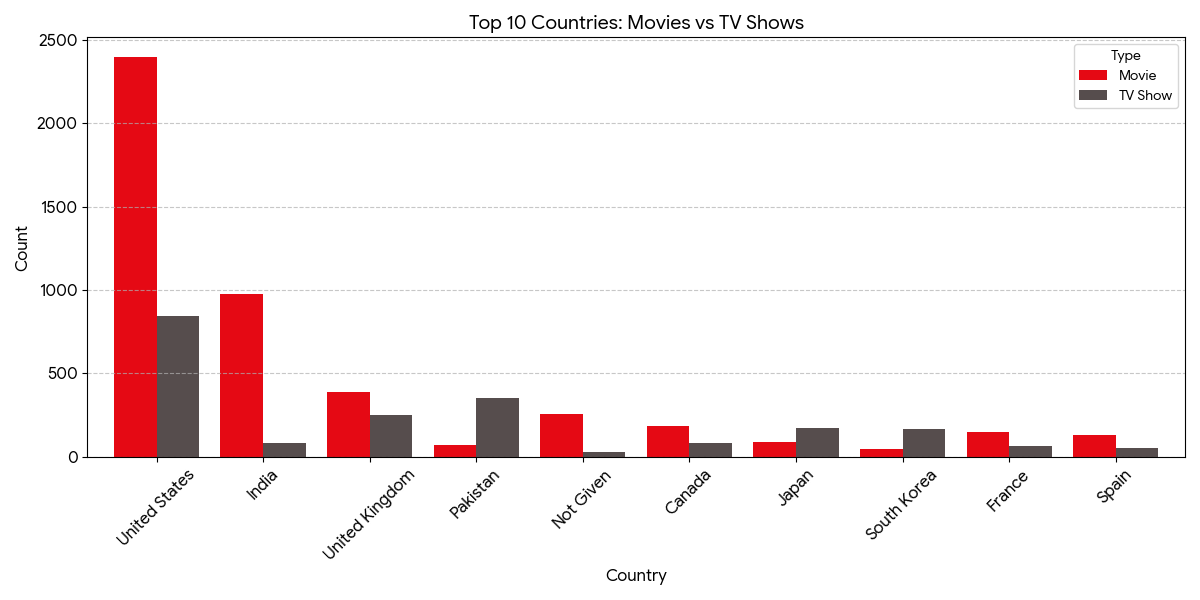

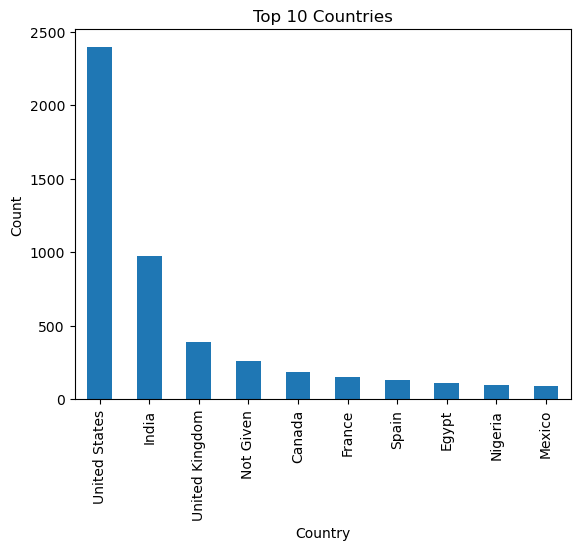

In [74]:
df1['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

### Show rating distribution

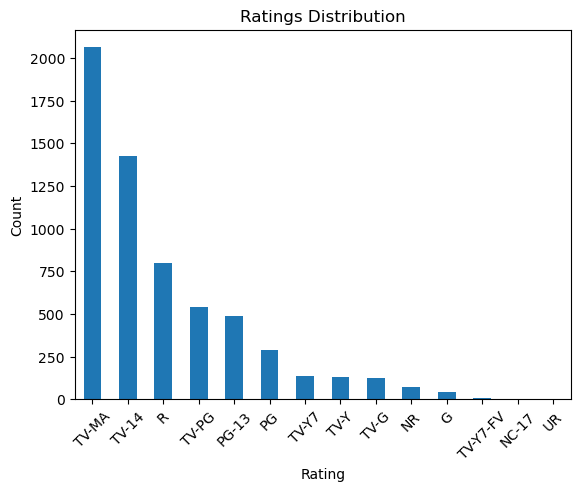

In [75]:
df1['rating'].value_counts().plot(kind='bar')
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Show top directors

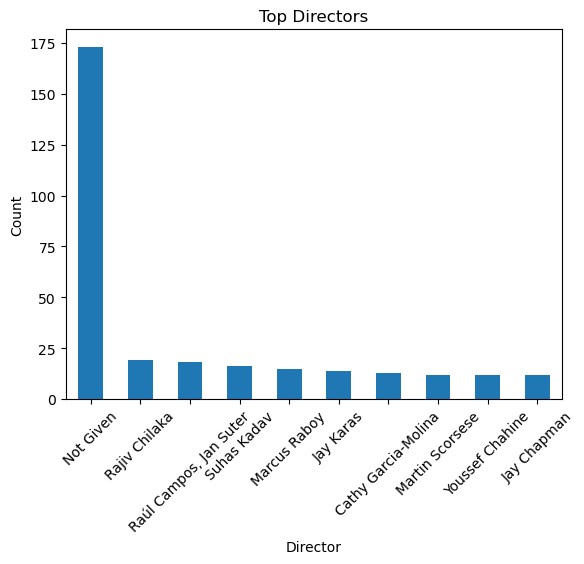

In [90]:
df1['director'].value_counts().head(10).plot(kind='bar')
plt.title('Top Directors')
plt.xlabel('Director')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()